In [1]:
# ============================================================
# Headline Keyword Analysis
# Identifying headline words associated with higher CTR
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import re
import string
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [2]:
import os

# 列出 MyDrive 下所有文件
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if file == 'dataset_final.csv':
            print(os.path.join(root, file))

/content/drive/MyDrive/Dissertation NewsCorp (26 July ddl)/dataset/dataset_final.csv


In [3]:
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for d in dirs:
        if 'phase 3' in d:
            print(os.path.join(root, d))

/content/drive/MyDrive/Dissertation NewsCorp (26 July ddl)/phase 3 Headline keyword analysis


In [4]:
# ============================================================
# GOOGLE DRIVE SETUP
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

# Input file path
input_path = '/content/drive/MyDrive/Dissertation NewsCorp (26 July ddl)/dataset/dataset_final.csv'

# Output directory
output_dir = '/content/drive/MyDrive/Dissertation NewsCorp (26 July ddl)/phase 3 Headline keyword analysis'
os.makedirs(output_dir, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [47]:
# ============================================================
# SECTION 1: DATA PREPROCESSING
# ============================================================

df = pd.read_csv(input_path)

# Check raw data size before cleaning
print(f"Raw dataset size: {df.shape[0]} rows, {df.shape[1]} columns")

# Keep only relevant columns
df = df[['title', 'clicked', 'category', 'subcategory']].copy()

# Remove missing values
df = df.dropna().reset_index(drop=True)
df = df[~df['category'].isin(['northamerica', 'kids'])].reset_index(drop=True)
print(f"Dataset size after cleaning: {df.shape}")

# --- Text Cleaning ---
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Lowercase
    text = text.lower()
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Tokenise
    tokens = text.split()
    # Remove stopwords and lemmatize
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return ' '.join(tokens)

df['title_clean'] = df['title'].apply(clean_text)
print("Text cleaning complete.")
print(df[['title', 'title_clean']].head(3))

Raw dataset size: 5843444 rows, 7 columns
Dataset size after cleaning: (5843253, 4)
Text cleaning complete.
                                               title  \
0  Charles Rogers, former Michigan State football...   
1  Porsche launches into second story of New Jers...   
2  Bode Miller delivered his twin boys after midw...   

                                         title_clean  
0  charles rogers former michigan state football ...  
1  porsche launch second story new jersey buildin...  
2  bode miller delivered twin boy midwife didnt m...  


In [48]:
# ============================================================
# SECTION 2: TF-IDF VECTORISATION
# ============================================================

tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=3000,
    ngram_range=(1, 2),
    min_df=5
)

X_tfidf = tfidf.fit_transform(df['title_clean'])
feature_names = tfidf.get_feature_names_out()

print(f"\nTF-IDF matrix shape: {X_tfidf.shape}")
print(f"Number of features: {len(feature_names)}")


TF-IDF matrix shape: (5843253, 3000)
Number of features: 3000



Keywords after filtering (min 100 impressions): 3000

Top 20 Highest CTR Keywords:
              keyword  total_impressions       ctr
0      actress laurel               6229  0.364424
1           griggs dy               6232  0.364249
2              dy age               6239  0.364161
3              age 13              13461  0.339054
4              griggs              13485  0.338450
5       laurel griggs              13485  0.338450
6              laurel              13515  0.338069
7    broadway actress               7043  0.325713
8            broadway              14420  0.318377
9         attack died               7229  0.317333
10           died age               7229  0.317333
11    griggs suffered               7229  0.317333
12    suffered asthma               7229  0.317333
13        star laurel               7233  0.317157
14      broadway star               7293  0.314822
15      asthma attack               8064  0.287574
16        later month               9908  0.28613

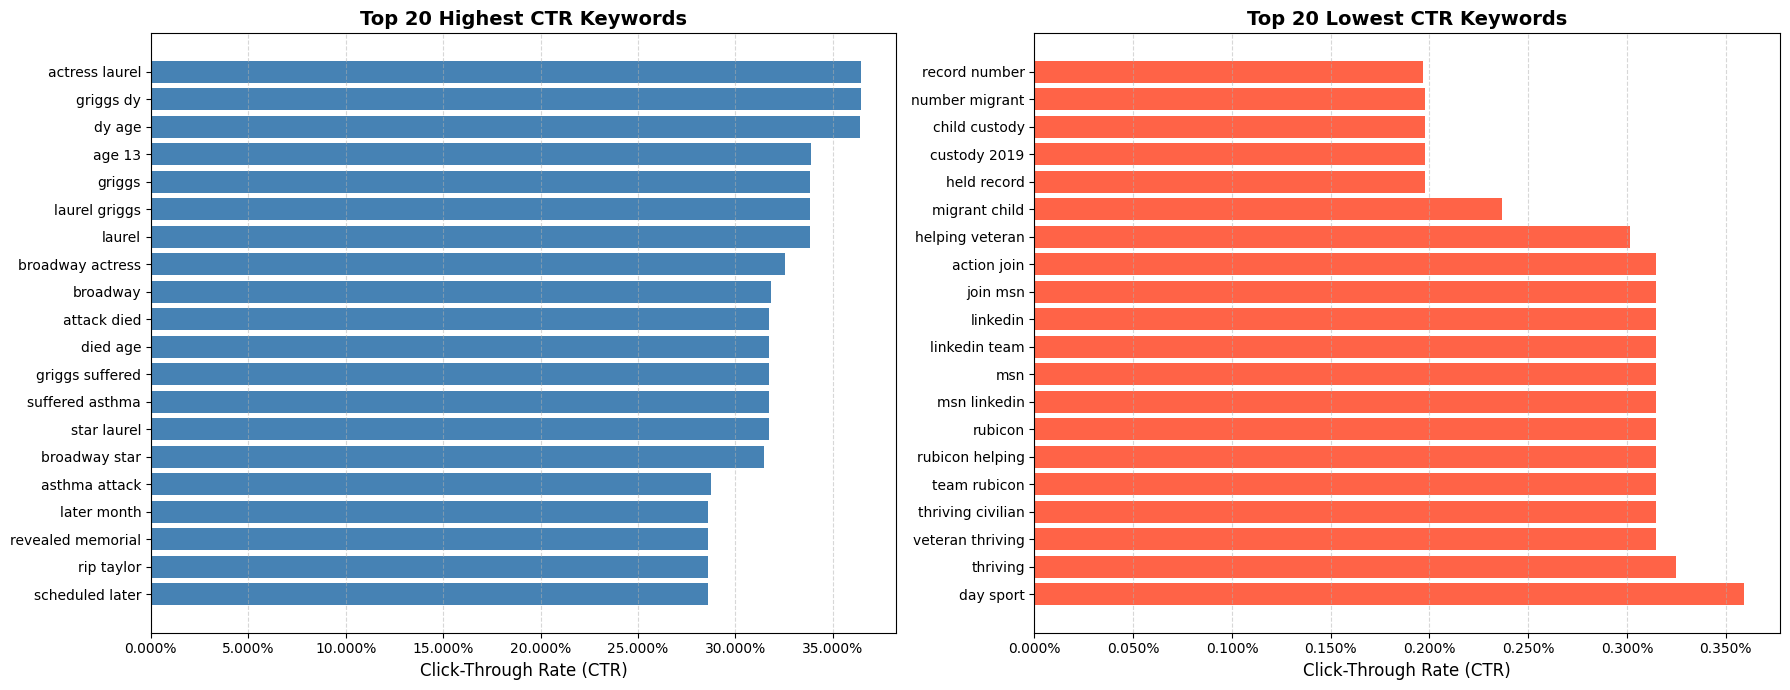

Saved: keyword_ctr_barchart.png


In [51]:
# ============================================================
# SECTION 3: KEYWORD CTR ANALYSIS
# ============================================================

# Convert TF-IDF to binary presence matrix (1 if keyword appears, 0 otherwise)
X_binary = (X_tfidf > 0).astype(int)

# Calculate total impressions and clicked impressions per keyword
total_impressions = X_binary.sum(axis=0).A1
clicked_impressions = X_binary.T.dot(df['clicked'].values)

# Build keyword CTR dataframe
keyword_ctr = pd.DataFrame({
    'keyword': feature_names,
    'total_impressions': total_impressions,
    'clicked_impressions': clicked_impressions
})

# Exclude keywords appearing fewer than 100 times
keyword_ctr = keyword_ctr[keyword_ctr['total_impressions'] >= 100].copy()

# Calculate CTR
keyword_ctr['ctr'] = keyword_ctr['clicked_impressions'] / keyword_ctr['total_impressions']

print(f"\nKeywords after filtering (min 100 impressions): {len(keyword_ctr)}")

# --- Top 20 Highest CTR Keywords ---
top20_high = keyword_ctr.nlargest(20, 'ctr').reset_index(drop=True)
print("\nTop 20 Highest CTR Keywords:")
print(top20_high[['keyword', 'total_impressions', 'ctr']])

# --- Top 20 Lowest CTR Keywords ---
top20_low = keyword_ctr.nsmallest(20, 'ctr').reset_index(drop=True)
print("\nTop 20 Lowest CTR Keywords:")
print(top20_low[['keyword', 'total_impressions', 'ctr']])

# --- Visualisation: High & Low CTR ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

axes[0].barh(top20_high['keyword'][::-1], top20_high['ctr'][::-1], color='steelblue')
axes[0].set_xlabel('Click-Through Rate (CTR)', fontsize=12)
axes[0].set_title('Top 20 Highest CTR Keywords', fontsize=14, fontweight='bold')
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0,decimals=3))
axes[0].grid(axis='x', linestyle='--', alpha=0.5)
axes[0].xaxis.set_major_locator(mtick.MultipleLocator(0.05))

axes[1].barh(top20_low['keyword'][::-1], top20_low['ctr'][::-1], color='tomato')
axes[1].set_xlabel('Click-Through Rate (CTR)', fontsize=12)
axes[1].set_title('Top 20 Lowest CTR Keywords', fontsize=14, fontweight='bold')
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(xmax= 1.0,decimals = 3))
axes[1].grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(f'{output_dir}/keyword_ctr_barchart.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: keyword_ctr_barchart.png")


Logistic Regression training complete.
Test accuracy: 0.6847

Top 20 Keywords Positively Associated with Clicks:
          keyword  coefficient
0        admitted     2.045081
1      supporting     1.971191
2           brown     1.927757
3          prison     1.921188
4           puppy     1.916041
5           thief     1.848869
6             eye     1.791919
7          taking     1.788391
8          linked     1.785946
9          laurel     1.783449
10          sarah     1.777460
11         bought     1.775587
12      following     1.742709
13         age 13     1.697125
14         scared     1.671997
15    commentator     1.666688
16         griggs     1.665083
17  laurel griggs     1.665083
18         creepy     1.663614
19      overnight     1.612048

Top 20 Keywords Negatively Associated with Clicks:
            keyword  coefficient
0         day sport    -2.748894
1          wildfire    -2.364722
2             troop    -2.363407
3           toddler    -2.003783
4           testin

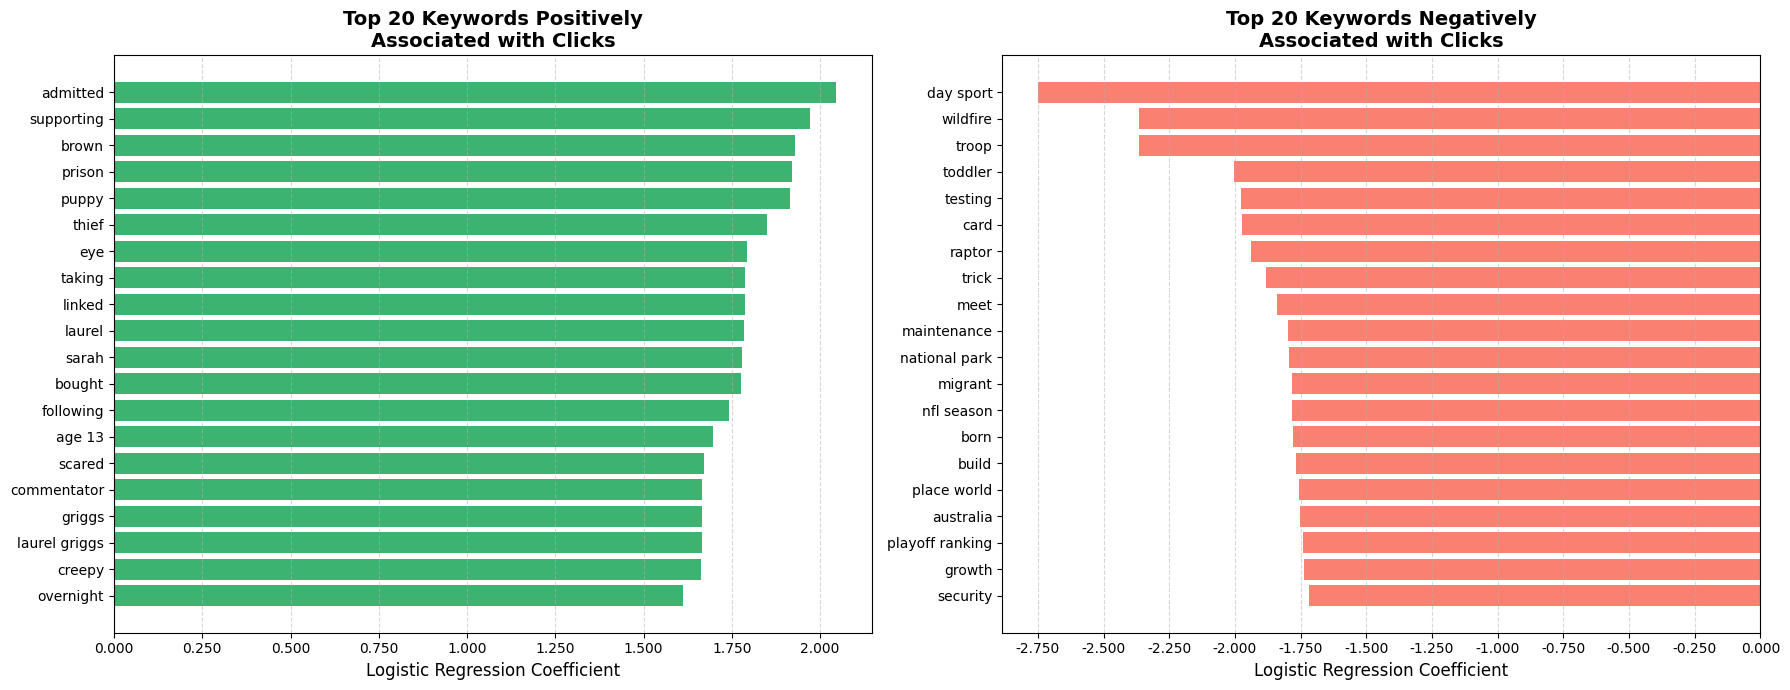

Saved: keyword_coefficients.png


In [52]:
# ============================================================
# SECTION 4: LOGISTIC REGRESSION ANALYSIS
# ============================================================

y = df['clicked'].values

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

# Fit logistic regression with balanced class weights
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

print(f"\nLogistic Regression training complete.")
print(f"Test accuracy: {lr.score(X_test, y_test):.4f}")

# Extract coefficients
coef_df = pd.DataFrame({
    'keyword': feature_names,
    'coefficient': lr.coef_[0]
})

# Top 20 positive (associated with clicks)
top20_pos = coef_df.nlargest(20, 'coefficient').reset_index(drop=True)
# Top 20 negative (associated with non-clicks)
top20_neg = coef_df.nsmallest(20, 'coefficient').reset_index(drop=True)

print("\nTop 20 Keywords Positively Associated with Clicks:")
print(top20_pos)
print("\nTop 20 Keywords Negatively Associated with Clicks:")
print(top20_neg)

# --- Visualisation: Coefficients ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

axes[0].barh(top20_pos['keyword'][::-1], top20_pos['coefficient'][::-1], color='mediumseagreen')
axes[0].set_xlabel('Logistic Regression Coefficient', fontsize=12)
axes[0].set_title('Top 20 Keywords Positively\nAssociated with Clicks', fontsize=14, fontweight='bold')
axes[0].grid(axis='x', linestyle='--', alpha=0.5)
axes[0].xaxis.set_major_formatter(mtick.FormatStrFormatter('%.3f'))

axes[1].barh(top20_neg['keyword'][::-1], top20_neg['coefficient'][::-1], color='salmon')
axes[1].set_xlabel('Logistic Regression Coefficient', fontsize=12)
axes[1].set_title('Top 20 Keywords Negatively\nAssociated with Clicks', fontsize=14, fontweight='bold')
axes[1].grid(axis='x', linestyle='--', alpha=0.5)
axes[1].xaxis.set_major_formatter(mtick.FormatStrFormatter('%.3f'))
axes[1].xaxis.set_major_locator(mtick.MultipleLocator(0.25))

plt.tight_layout()
plt.savefig(f'{output_dir}/keyword_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: keyword_coefficients.png")

In [53]:
# ============================================================
# SECTION 5: TOPIC-LEVEL ENGAGEMENT ANALYSIS
# ============================================================

# CTR by category
category_ctr = (
    df.groupby('category')['clicked']
    .agg(total='count', clicks='sum')
    .assign(ctr=lambda x: x['clicks'] / x['total'])
    .sort_values('ctr', ascending=False)
    .reset_index()
)

category_mean_ctr = category_ctr['ctr'].mean()
print(f"\nCTR by Category:")
print(category_ctr)
print(f"\nMean CTR by Category: {category_mean_ctr:.3%}")


CTR by Category:
         category    total  clicks       ctr
0           music   269008   15988  0.059433
1              tv   246462   14544  0.059011
2         weather    88646    4582  0.051689
3          sports   592226   28181  0.047585
4           video    93744    4262  0.045464
5            news  1591038   69408  0.043624
6       lifestyle   655440   26584  0.040559
7         finance   564671   20597  0.036476
8          health   304088   10863  0.035723
9          movies   132091    4186  0.031690
10  entertainment   349930   10530  0.030092
11   foodanddrink   369382   10883  0.029463
12          autos   271426    7428  0.027367
13         travel   315101    8304  0.026353

Mean CTR by Category: 4.032%


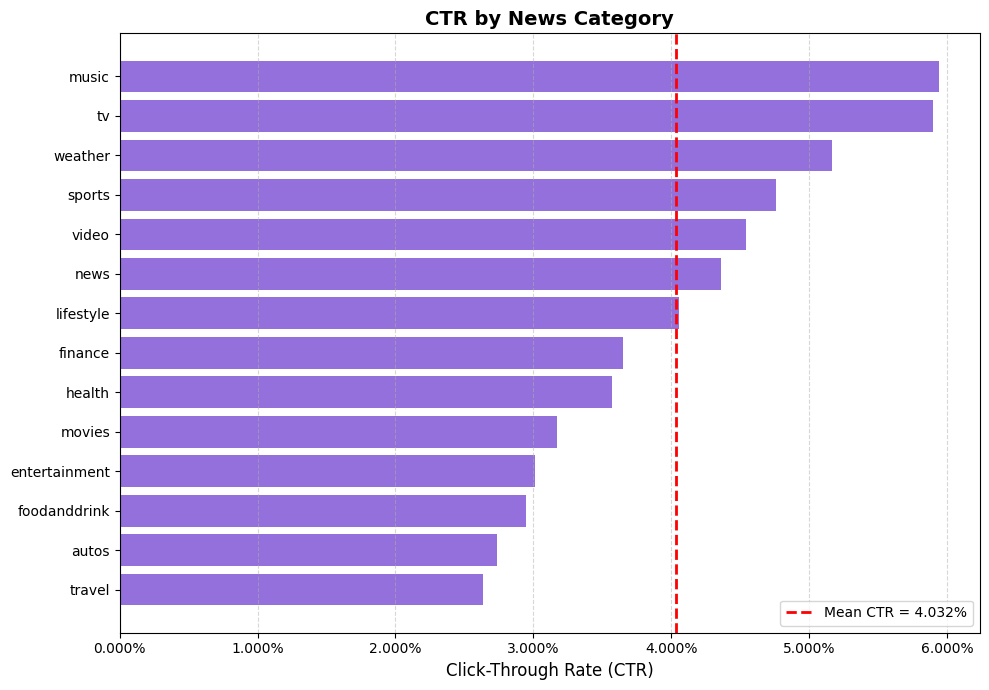

Saved: ctr_by_category.png


In [54]:
fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(
    category_ctr['category'][::-1],
    category_ctr['ctr'][::-1],
    color='mediumpurple'
)

ax.set_xlabel('Click-Through Rate (CTR)', fontsize=12)
ax.set_title('CTR by News Category', fontsize=14, fontweight='bold')

ax.xaxis.set_major_formatter(
    mtick.PercentFormatter(xmax=1.0, decimals=3)
)

ax.xaxis.set_major_locator(
    mtick.MultipleLocator(0.01)
)

ax.grid(axis='x', linestyle='--', alpha=0.5)

#mean line
ax.axvline(
    category_mean_ctr,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Mean CTR = {category_mean_ctr:.3%}'
)

ax.legend()

plt.tight_layout()

plt.savefig(
    f'{output_dir}/ctr_by_category.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print("Saved: ctr_by_category.png")

In [55]:
# CTR by subcategory (top 15)
subcategory_ctr = (
    df.groupby('subcategory')['clicked']
    .agg(total='count', clicks='sum')
    .assign(ctr=lambda x: x['clicks'] / x['total'])
    .sort_values('ctr', ascending=False)
    .reset_index()
)
top20_subcat = subcategory_ctr.head(15)

print("\nCTR by Subcategory (top 15):")
print(top20_subcat)



CTR by Subcategory (top 15):
               subcategory   total  clicks       ctr
0              tennis_intl       2       1  0.500000
1       pregnancyparenting      48       6  0.125000
2                   sports       8       1  0.125000
3              sports_news   11929    1296  0.108643
4                  topnews    6214     652  0.104924
5                musicnews   51629    4665  0.090356
6          music-celebrity   97967    8274  0.084457
7            music-reviews      12       1  0.083333
8                   tvnews   79725    6541  0.082045
9              newsopinion   28448    2217  0.077932
10               newscrime  203292   14343  0.070554
11  finance-small-business     187      12  0.064171
12            mentalhealth    6101     390  0.063924
13            football_nfl  244383   15590  0.063793
14                 indepth    4870     303  0.062218


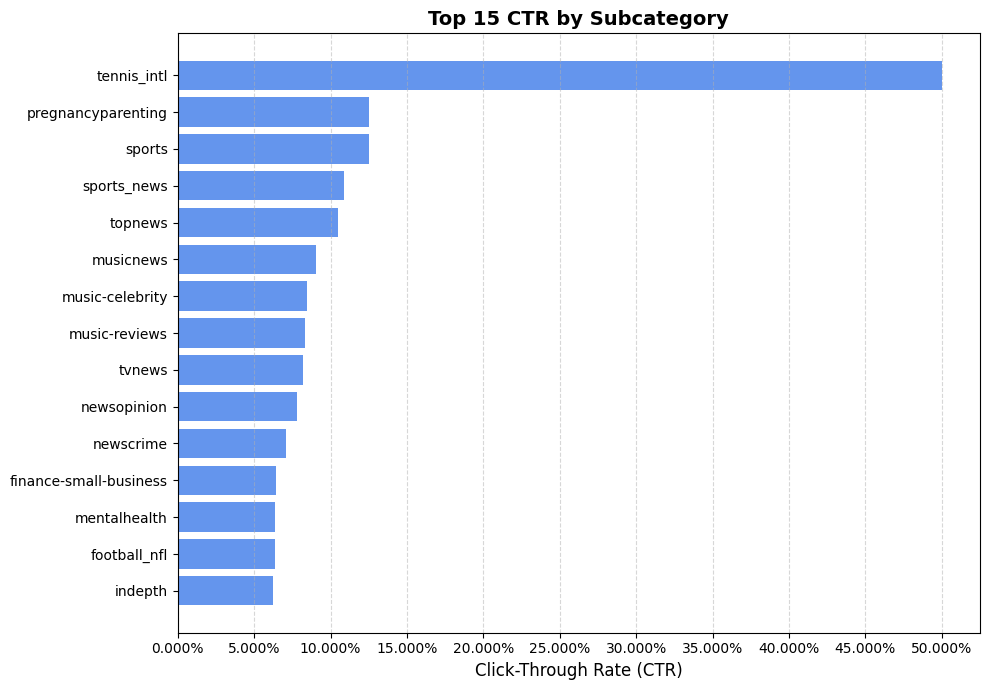

Saved: ctr_by_subcategory_top15.png


In [56]:
fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(
    top20_subcat['subcategory'][::-1],
    top20_subcat['ctr'][::-1],
    color='cornflowerblue'
)

ax.set_xlabel('Click-Through Rate (CTR)', fontsize=12)
ax.set_title('Top 15 CTR by Subcategory', fontsize=14, fontweight='bold')

ax.xaxis.set_major_formatter(
    mtick.PercentFormatter(xmax=1.0, decimals=3)
)

ax.xaxis.set_major_locator(
    mtick.MultipleLocator(0.05)
)

ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.savefig(
    f'{output_dir}/ctr_by_subcategory_top15.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print("Saved: ctr_by_subcategory_top15.png")

In [57]:
# ============================================================
# SECTION 6: EXPORT OUTPUTS
# ============================================================

# High / Low CTR keyword lists
top20_high.to_csv(f'{output_dir}/high_ctr_keywords.csv', index=False)
top20_low.to_csv(f'{output_dir}/low_ctr_keywords.csv', index=False)

# Full keyword CTR table
keyword_ctr.sort_values('ctr', ascending=False).to_csv(f'{output_dir}/keyword_ctr_full.csv', index=False)

# Coefficient table
coef_df.sort_values('coefficient', ascending=False).to_csv(f'{output_dir}/keyword_coefficients.csv', index=False)

# Topic engagement
category_ctr.to_csv(f'{output_dir}/category_engagement.csv', index=False)
subcategory_ctr.to_csv(f'{output_dir}/subcategory_engagement.csv', index=False)

print("\n=== All outputs saved to Google Drive ===")
print(f"Location: {output_dir}")
print("Files saved:")
print("  - keyword_ctr_barchart.png")
print("  - keyword_coefficients.png")
print("  - ctr_by_category.png")
print("  - ctr_by_subcategory_top15.png")
print("  - high_ctr_keywords.csv")
print("  - low_ctr_keywords.csv")
print("  - keyword_ctr_full.csv")
print("  - keyword_coefficients.csv")
print("  - category_engagement.csv")
print("  - subcategory_engagement.csv")


=== All outputs saved to Google Drive ===
Location: /content/drive/MyDrive/Dissertation NewsCorp (26 July ddl)/phase 3 Headline keyword analysis
Files saved:
  - keyword_ctr_barchart.png
  - keyword_coefficients.png
  - ctr_by_category.png
  - ctr_by_subcategory_top15.png
  - high_ctr_keywords.csv
  - low_ctr_keywords.csv
  - keyword_ctr_full.csv
  - keyword_coefficients.csv
  - category_engagement.csv
  - subcategory_engagement.csv
